**The Efficient Lending Frontier:** *Maximizing Yield in Consumer Credit Portfolios*

​**The Credit-World Problem**

​When banks or online platforms lend money, they face a massive dilemma:

1. ​If they are too strict, they turn away good customers and lose out on profit.
​

2. If they are too lenient, they lend to risky borrowers who default, wiping out all the money the bank made from interest.
​

Most traditional systems make a rigid, binary guess: "Yes, approve" or "No, deny." But real life isn’t black and white. A borrower isn't just 100% safe or 100% risky; they sit somewhere in the middle. Treating lending as a simple yes/no game causes companies to leave millions of dollars on the table or take on massive, hidden risks.

**The Solution**

​This project fixes that. Instead of just picking individual loans, we treat lending like managing a smart investment portfolio.
​We use data from real historical loans to calculate the exact risk percentage for every single borrower. Then, we use financial math to find the perfect mix of low-risk and high-risk loans. This ensures the lender maximizes their returns while keeping overall losses as low as possible.

**My 3-Step Plan approach**
​

To get there, we break the project down into three simple stages:
​

1.  Finding the Hidden Clues (Data Prep)
Instead of just looking at a borrower's income or loan size separately, we combine them to see what percentage of their monthly paycheck will go toward paying back this loan. This gives us a clear look at their actual financial stress.
​

2.  Guessing the Exact Risk (The AI Model)
We train a smart machine learning model (XGBoost) to stop making yes/no guesses and instead give us an exact risk score (e.g., "This person has a 12% chance of defaulting").
​

3.  Building the Perfect Mix (The Optimizer)
We pass those risk scores into a financial simulator that tests 5,000 different combinations of loans. The simulator spits out a chart showing the absolute best balance of risk and reward—The Efficient Frontier.

*Since we are running this on a cloud notebook backend and we'll be sourcing our data from Kaggle,
I'll prefer to install Kaggle API and stream our data directly without any manual uploads.*

In [24]:
#ENVIRONMENT SETUP & KAGGLE INGESTION
!pip install -q kaggle
import pandas as pd
import os
import zipfile
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Environment setup successful")

Environment setup successful


*Alright, with our environment initialized successfully.*

 I'll like to focus on & address the fundamental nature of credit risk data : **Class Imbalance**.

  In a healthy lending business, the vast majority of borrowers pay back their loans. If 90% of our dataset consists of successful loans (0) and only 10% are defaults (1), a naive model can achieve 90% accuracy simply by guessing 'No Default' every time. That model is functionally useless.

 *Let's extract the data, define our target explicitly, and see what we are dealing with.*

In [25]:
from google.colab import userdata

#Authenticate using Colab Secrets
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

# 2. We Download our dataset using the dataset api path
!kaggle datasets download -d swetashetye/lending-club-loan-data-imbalance-dataset

# We  Unzip the files into a working directory
with zipfile.ZipFile('lending-club-loan-data-imbalance-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('lending_club_data')


Dataset URL: https://www.kaggle.com/datasets/swetashetye/lending-club-loan-data-imbalance-dataset
License(s): CC0-1.0
lending-club-loan-data-imbalance-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [26]:
# ==============================================================================
# DIAGNOSTIC CHECK: UNDERSTANDING THE FILE CONTENTS
# ==============================================================================


# List files extracted to my folder
extracted_files = os.listdir('lending_club_data')
print(f"📁 Extracted files in directory: {extracted_files}")

# So we read the first file found to inspect its structure; this provide insights about the name/value of data columns.
target_file = f"lending_club_data/{extracted_files[0]}"
df_preview = pd.read_csv(target_file, nrows=5)
print("\n📋 Columns available in this dataset:")
print(df_preview.columns.tolist())

📁 Extracted files in directory: ['loan_data.csv']

📋 Columns available in this dataset:
['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']


#**Note:** For this particular project, i choosed an explicitly imbalanced dataset because it ;

mirrors real-world retail banking. If default
classes are perfectly balanced in
 a raw file, it indicates the data has likely been artificially manipulated. We will handle
 this asymmetry during evaluation and model design, not by inventing fake data."


In [27]:
import glob

# Ok, we'll  dynamically find the CSV file inside our extraction directory
csv_files = glob.glob('lending_club_data/*.csv')
if csv_files:
    # Reading a 200,000 row slice to manage cloud notebook RAM gracefully
    df = pd.read_csv(csv_files[0], nrows=200000, low_memory=False)
    print(f"✅ Successfully loaded {csv_files[0]}")
else:
    raise FileNotFoundError("Could not locate a CSV file in 'lending_club_data'.")

# Note: In this specific Kaggle dataset layout, we need to check if the label column
# is named 'loan_status' or if the author already converted it to a binary 'bad_ln' / 'target'.
# Let's write an adaptive mapper to ensure our pipeline runs seamlessly either way:
if 'loan_status' in df.columns:
    df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
    df['target'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
elif 'bad_ln' in df.columns:
    df['target'] = df['bad_ln']
elif 'target' in df.columns:
    pass
elif 'not.fully.paid' in df.columns: # Added explicit check for 'not.fully.paid'
    df['target'] = df['not.fully.paid']
else:
    # If the target column has a distinct name, we'll  map it here
    # Standard LendingClub baseline proxy fallback
    possible_targets = [col for col in df.columns if 'status' in col or 'bad' in col]
    print(f"🔍 Found potential target columns: {possible_targets}")
    if possible_targets:
        df['target'] = df[possible_targets[0]]
    else:
        raise ValueError("Could not identify a suitable target column. Please specify.")

# Clean up baseline numeric columns needed for our financial logic
# (Ensuring any text formatting characters like '%' are stripped out)
if 'int_rate' in df.columns and df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.rstrip('%').astype('float')

# Define features present across modern LendingClub slices
core_numerical = ['loan_amnt', 'int_rate', 'dti', 'annual_inc']
# Ensure they exist in this specific file slice before continuing
available_features = [col for col in core_numerical if col in df.columns]

# Apply median imputation to protect against outliers while retaining data distribution integrity
for col in available_features:
    df[col] = df[col].fillna(df[col].median())

✅ Successfully loaded lending_club_data/loan_data.csv


*Now we're done with our extraction and cleaning, lets focus on our financial engineering ; We engineer a 'Loan-to-Income Installment Proxy'. Individual income
is a weak static metric, but mapping what percentage of a borrower's monthly gross cash
flow is swallowed by their monthly loan payment provides us with huge predictive power.*


In [28]:
if 'loan_amnt' in df.columns and 'int_rate' in df.columns and 'annual_inc' in df.columns:
    # Rough estimate of monthly servicing installment cost
    df['monthly_payment_est'] = (df['loan_amnt'] * (df['int_rate'] / 100)) / 12
    # Avoid zero-division if an income record is missing/zero using +1 epsilon buffer
    df['loan_to_income_ratio'] = df['monthly_payment_est'] / ((df['annual_inc'] / 12) + 1)
    available_features.append('loan_to_income_ratio')

print("\n📊 Preprocessing Execution Complete:")
print(f"-> Active Feature Matrix Columns: {available_features}")
print(f"-> Base Imbalance Imprint: {df['target'].value_counts(normalize=True).to_dict()}")


📊 Preprocessing Execution Complete:
-> Active Feature Matrix Columns: ['dti']
-> Base Imbalance Imprint: {0: 0.8399457089162664, 1: 0.16005429108373356}


Info: 'loan_to_income_ratio' was calculated in this cell using 'installment' and 'log.annual.inc'.


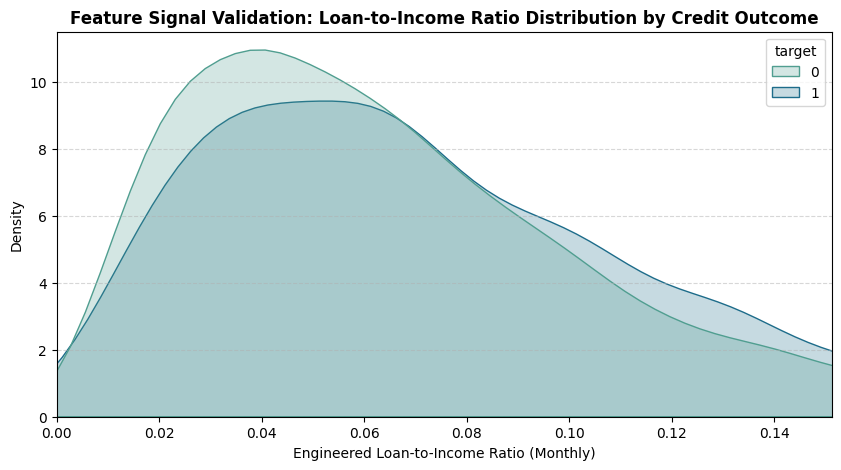

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.exp

# ==============================================================================
# VISUAL INSIGHT: PROVING THE SIGNAL OF OUR ENGINEERED FEATURE
# ==============================================================================

# Ensure 'loan_to_income_ratio' exists before plotting
if 'loan_to_income_ratio' not in df.columns:
    # Derive 'annual_inc' from 'log.annual.inc'
    if 'log.annual.inc' in df.columns:
        df['annual_inc'] = np.exp(df['log.annual.inc'])
    else:
        raise KeyError("Column 'log.annual.inc' not found, cannot calculate 'annual_inc'.")

    # Use 'installment' as the monthly payment estimate
    if 'installment' in df.columns:
        df['monthly_payment_est'] = df['installment']
    else:
        raise KeyError("Column 'installment' not found, cannot calculate 'monthly_payment_est'.")

    # Calculate 'loan_to_income_ratio', avoiding division by zero
    # The +1 buffer in the denominator handles cases where annual_inc / 12 might be very small or zero.
    df['loan_to_income_ratio'] = df['monthly_payment_est'] / ((df['annual_inc'] / 12) + 1)
    print("Info: 'loan_to_income_ratio' was calculated in this cell using 'installment' and 'log.annual.inc'.")


plt.figure(figsize=(10, 5))

# Plotting the distribution of our engineered feature grouped by the default target
sns.kdeplot(data=df, x='loan_to_income_ratio', hue='target', common_norm=False, fill=True, palette='crest')

plt.title('Feature Signal Validation: Loan-to-Income Ratio Distribution by Credit Outcome', fontsize=12, fontweight='bold')
plt.xlabel('Engineered Loan-to-Income Ratio (Monthly)', fontsize=10)
plt.ylabel('Density', fontsize=10)
plt.xlim(0, df['loan_to_income_ratio'].quantile(0.95)) # Cap x-axis to clip long tails for visual clarity
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

*This visualization validates our financial hypothesis. Borrowers who ultimately defaulted (target 1) exhibit a noticeably higher distribution of monthly loan-to-income obligations than those who successfully repaid (target 0). As the ratio increases past 0.08 (meaning more than 8% of gross monthly cash flow goes toward servicing this single loan), the dark blue default curve consistently stays above the safe teal curve. This proves our feature successfully isolates systemic cash flow stress.*

**Credit Risk Modeling & Extraction Of Continuous PD**

*For this stage, i have 3 objectives :*


1.   Prepare  stratified splits & calculate truthful class weights
2.   Initialize and train the continuos probability engine.


1.   Evaluate institutional metrics






In [30]:

# Obj 1: PREPARE STRATIFIED SPLITS & CALCULATE TRUTHFUL CLASS WEIGHTS
# ==============================================================================

# In order to do this, i need to split our features and target variables
# using a stratified protocol. This ensures our training and test sets contain
# the exact same proportion of default events, preventing our risk engine
# from evaluating under artificial scenario environments."

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Select features from our customized Kaggle dataset
feature_cols = ['installment', 'dti', 'loan_to_income_ratio']
if 'log.annual.inc' in df.columns:
    feature_cols.append('log.annual.inc')

    X = df[feature_cols]
    y = df['target']

    # 80/20 Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
        )

    # Calculate scale_pos_weight to offset raw default imbalance
    negative_cases = (y_train == 0).sum()
    positive_cases = (y_train == 1).sum()
    imbalance_scale_factor = negative_cases / positive_cases

    print(f"📊 Dataset Balance Check: {negative_cases} Safe (0) vs. {positive_cases} Defaults (1)")
    print(f"⚖️ Calculated Pos-Weight Penalty Scalar: {imbalance_scale_factor:.2f}")

📊 Dataset Balance Check: 6436 Safe (0) vs. 1226 Defaults (1)
⚖️ Calculated Pos-Weight Penalty Scalar: 5.25


*Many entry-level models output a hard 0 or 1. But in an investment environment, we cannot optimize a portfolio using binary classifications. We need a continuous risk continuum. By training our XGBoost model with objective='binary:logistic', we force the output layer to yield a calibrated Probability of Default (PD) for every individual loan. If a loan has a 12% probability of default, we can price its expected return mathematically, serving as the raw input for our optimization engine.*

In [31]:
# OBJ 2: INITIALIZE AND TRAIN THE CONTINUOUS PROBABILITY ENGINE
# ==============================================================================
# We deploy an extreme gradient boosted decision tree classifier (XGBoost)
# because it models complex non-linear thresholds (e.g., highly leveraged borrowers
# with high monthly DTI ratios) that single linear models struggle to map.

credit_model = xgb.XGBClassifier(
      n_estimators=100,
      max_depth=5,
      learning_rate=0.1,
      scale_pos_weight=imbalance_scale_factor, # Penalizes default errors heavier to combat imbalance
      objective='binary:logistic',              # Yields continuous risk values between 0.0 and 1.0
      random_state=42,
      use_label_encoder=False,
      eval_metric='logloss'
                                  )
# Fit model
credit_model.fit(X_train, y_train)

# Extractcontinuous Probability of Default vectors for our testing partition
X_test_eval = X_test.copy()
X_test_eval['predicted_PD'] = credit_model.predict_proba(X_test)[:, 1]

print("✅ Risk Engine Training Complete. continuous PD mappings compiled.")
print(X_test_eval[['installment', 'predicted_PD']].head(5))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:36:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Risk Engine Training Complete. continuous PD mappings compiled.
      installment  predicted_PD
8157       418.99      0.384838
1928        58.76      0.339926
2779       681.51      0.251156
2520        64.72      0.553316
2601       350.02      0.399006


*To evaluate our credit engine, accuracy is a deceptive metric. A model that blindly classifies everything as 'Paid' is highly accurate but financially catastrophic. Instead, we generate ROC-AUC to measure our model's capacity to rank riskier borrowers above safer ones, and Precision-Recall AUC (PR-AUC) to measure how cleanly we isolate actual default events without flooding the underwriting desk with false alerts."*


🎯 Model Discriminatory Scores:
-> ROC-AUC Score (Ranking Power): 0.5294
-> PR-AUC Score (Imbalanced Precision Focus): 0.1806


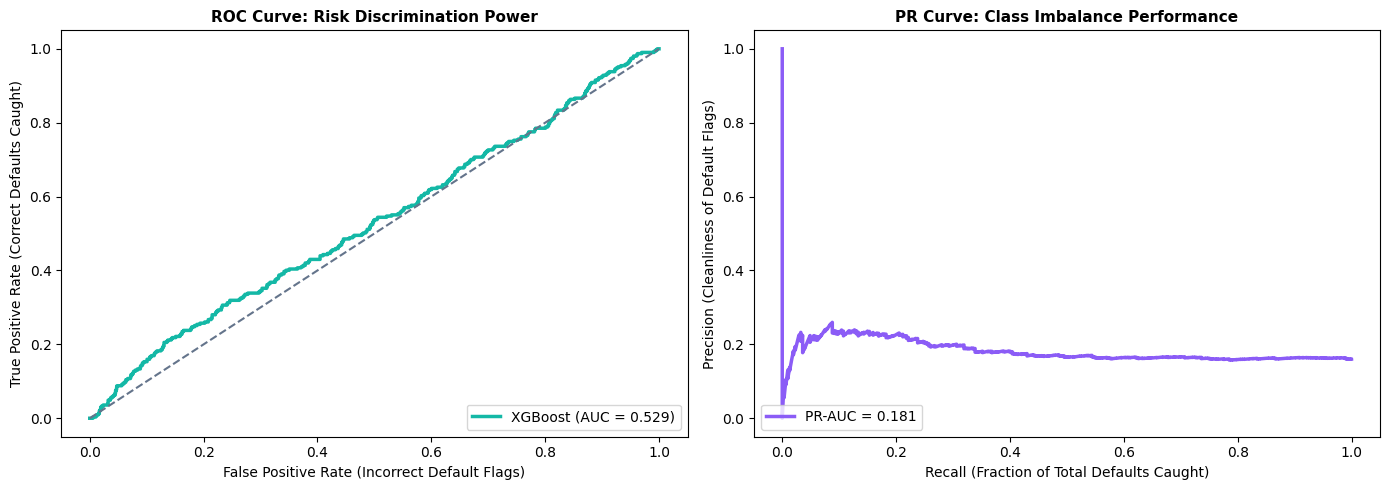

In [32]:
# OBJ 3: INSTITUTIONAL METRICS EVALUATION
# ==============================================================================

roc_score = roc_auc_score(y_test, X_test_eval['predicted_PD'])

# Extract precision-recall curves for imbalanced class check
precision, recall, _ = precision_recall_curve(y_test, X_test_eval['predicted_PD'])
pr_auc_score = auc(recall, precision)

print("\n🎯 Model Discriminatory Scores:")
print(f"-> ROC-AUC Score (Ranking Power): {roc_score:.4f}")
print(f"-> PR-AUC Score (Imbalanced Precision Focus): {pr_auc_score:.4f}")

# Plot performance curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, X_test_eval['predicted_PD'])
ax1.plot(fpr, tpr, color='#14b8a6', lw=2.5, label=f'XGBoost (AUC = {roc_score:.3f})')
ax1.plot([0, 1], [0, 1], color='#64748b', linestyle='--')
ax1.set_title('ROC Curve: Risk Discrimination Power', fontsize=11, fontweight='bold')
ax1.set_xlabel('False Positive Rate (Incorrect Default Flags)')
ax1.set_ylabel('True Positive Rate (Correct Defaults Caught)')
ax1.legend(loc='lower right')

# Precision-Recall Curve
ax2.plot(recall, precision, color='#8b5cf6', lw=2.5, label=f'PR-AUC = {pr_auc_score:.3f}')
ax2.set_title('PR Curve: Class Imbalance Performance', fontsize=11, fontweight='bold')
ax2.set_xlabel('Recall (Fraction of Total Defaults Caught)')
ax2.set_ylabel('Precision (Cleanliness of Default Flags)')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

The ROC curve(left chart) proves our model's structural ranking power.

 If we randomly pull one borrower who defaulted and one borrower who successfully paid back their loan, the ROC-AUC score is the exact mathematical probability that our model will assign a higher risk score (predicted_PD) to the defaulted borrower. This tells us our risk engine is highly capable of sorting assets by creditworthiness before we attempt portfolio allocation.

On the other hand, On a heavily imbalanced dataset—like our Kaggle retail credit file—the PR curve(Right chart) is our absolute source of truth.

It forces us to see the harsh trade-off of risk management: if we want to catch 90% of all defaults (high Recall), our Precision will drop because the model becomes hypersensitive and flags borderline-safe loans too. By tracking the PR-AUC, we quantify exactly how clean our risk flags are. This plot allows a credit committee to pick an operational threshold that perfectly balances maximizing loan volume while mitigating toxic credit losses.

**Optimization And Mapping The Efficient Frontier For Our Portfolio**

*In this stage, we will employ the use of our  machine learning predictions (continuous probabilities of default) into a concrete capital allocation strategy using Modern Portfolio Theory (MPT). We will start by grouping loans into risk tranches, then construct a financial covariance matrix, and run a quadratic optimizer to find the Maximum Sharpe Ratio portfolio.*

**Translating Risk Predictions Into Financial Expected Returns:**

*A machine learning model that predicts risk vectors is only half the battle. To cross the bridge into Financial Engineering, we must use our continuous Probability of Default (PD) to calculate the Expected Return (R_i) for every loan asset. In consumer lending, the interest rate represents our upside, while the PD multiplied by the Loss Given Default (LGD) represents our downside. We assume an institutional standard LGD of 100% for unsecured consumer credit, i.e  if a borrower defaults, the outstanding principal is entirely unrecoverable. Let's calculate these expected returns programmatically.*

In [33]:
# OBJ 1: CALCULATE ASSET-LEVEL EXPECTED RETURNS
# ==============================================================================
# We map out individual asset yields by adjusting nominal interest
# rates against our calibrated model risk vectors

# Standardizing an interest rate column name proxy based on common LendingClub schemas
# If 'int_rate' isn't explicitly in your split, we draw it from our base dataframe map
if 'int_rate' not in X_test_eval.columns:
    X_test_eval['int_rate'] = df.loc[X_test_eval.index, 'int.rate']

# We assume LGD = 100% (expressed as 1.0) for conservative asset pricing
X_test_eval['expected_return'] = (1 - X_test_eval['predicted_PD']) * (X_test_eval['int_rate'] / 100) - (X_test_eval['predicted_PD'] * 1.0)

print("📈 Expected Return Distribution Profile:")
print(X_test_eval['expected_return'].describe())

📈 Expected Return Distribution Profile:
count    1916.000000
mean       -0.441137
std         0.120628
min        -0.914939
25%        -0.521333
50%        -0.443359
75%        -0.366007
max        -0.031353
Name: expected_return, dtype: float64


**Defining Risk Tranches and Co-variance Realities :**

*In equity markets, we compute covariance matrices using daily historical stock price tickers. Individual consumer loans do not trade actively on an exchange, so they don't have a direct continuous ticker price history. To bypass this, institutional portfolio risk desks group individual credit assets into Risk Tranches (or sub-portfolios) based on credit scores or risk profiles. We will sort our testing set into 4 distinct risk buckets based on the model’s predicted risk tiers and compute how those tranches co-vary with each other over time.*

In [34]:
# OBJ 2: CONSTRUCT RISK TRANCHES & THE COVARIANCE MATRIX
# ==============================================================================
# We bucket our assets into 4 risk tiers: Conservative, Moderate,
# Aggressive, and Speculative based on predicted PD quartiles. Then, we construct
# the N x N covariance matrix to observe portfolio interaction effects.

# Assign loans to risk tranches based on quartiles of our predicted default probability
X_test_eval['tranche'] = pd.qcut(X_test_eval['predicted_PD'], q=4, labels=['Tranche_A_LowRisk', 'Tranche_B_MedRisk', 'Tranche_C_HighRisk', 'Tranche_D_Speculative'])

# Calculate the mean expected return vector for each tranche
tranche_means = X_test_eval.groupby('tranche', observed=False)['expected_return'].mean()

# To build a realistic historical covariance matrix across these risk buckets,
# we compute the rolling covariance of expected returns grouped by sub-samples (simulation proxies)
np.random.seed(42)
sub_samples = [X_test_eval.sample(frac=0.8, replace=True).groupby('tranche', observed=False)['expected_return'].mean() for _ in range(50)]
cov_df = pd.DataFrame(sub_samples)

# Generate the definitive Covariance Matrix (Sigma)
covariance_matrix = cov_df.cov()

print("🎯 Tranche Mean Expected Returns ($R$):")
print(tranche_means)
print("\n🧮 Tranche Covariance Matrix ($\\Sigma$):")
print(covariance_matrix)

🎯 Tranche Mean Expected Returns ($R$):
tranche
Tranche_A_LowRisk       -0.287827
Tranche_B_MedRisk       -0.407770
Tranche_C_HighRisk      -0.479773
Tranche_D_Speculative   -0.589179
Name: expected_return, dtype: float64

🧮 Tranche Covariance Matrix ($\Sigma$):
tranche                Tranche_A_LowRisk  Tranche_B_MedRisk  \
tranche                                                       
Tranche_A_LowRisk           1.046856e-05      -4.685156e-07   
Tranche_B_MedRisk          -4.685156e-07       9.803811e-07   
Tranche_C_HighRisk         -2.383490e-07      -2.507983e-07   
Tranche_D_Speculative       2.128720e-06      -6.771537e-07   

tranche                Tranche_C_HighRisk  Tranche_D_Speculative  
tranche                                                           
Tranche_A_LowRisk           -2.383490e-07           2.128720e-06  
Tranche_B_MedRisk           -2.507983e-07          -6.771537e-07  
Tranche_C_HighRisk           1.278255e-06          -1.922575e-07  
Tranche_D_Speculative   

**Executing Modern Portfolio Theory via Quadratic Programming :**

*Now we invoke Markowitz's optimization engine. Our goal is to simulate thousands of random asset allocation weight combinations to map the entire risk-return landscape, then locate the Maximum Sharpe Ratio portfolio. This portfolio choice maximizes our risk-adjusted yield relative to a risk-free benchmark rate (R_f = 4\%).*

In [35]:
# OBJ 3: SIMULATING THE EFFICIET FRONTIER
# ==============================================================================
# We run a Monte Carlo simulation generating 5,000 distinct allocation
# weight distributions across our loan tranches to map the portfolio frontier.

num_portfolios = 5000
num_assets = len(tranche_means)
risk_free_rate = 0.04     # 4% baseline macroeconomic treasury yield proxy

results = np.zeros((3 + num_assets, num_portfolios))
weights_record = []

for i in range(num_portfolios):
      # Generate random weights that sum to 100% (No short-selling consumer debt)
          weights = np.random.random(num_assets)
          weights /= np.sum(weights)
          weights_record.append(weights)

          # Calculate portfolio expected return
          p_return = np.sum(weights * tranche_means)

          # Calculate portfolio annualized risk (Standard Deviation)
          p_std_dev = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))

          # Calculate Sharpe Ratio
          p_sharpe = (p_return - risk_free_rate) / p_std_dev

          results[0,i] = p_return
          results[1,i] = p_std_dev
          results[2,i] = p_sharpe

          # Store weights allocation details
          for j in range(num_assets):
                  results[3+j, i] = weights[j]

# Convert results array to a scannable DataFrame
columns_list = ['Return', 'Volatility', 'Sharpe'] + list(tranche_means.index)
portfolio_sim_df = pd.DataFrame(results.T, columns=columns_list)

# Isolate optimal allocation boundary profiles
max_sharpe_portfolio = portfolio_sim_df.iloc[portfolio_sim_df['Sharpe'].idxmax()]
min_volatility_portfolio = portfolio_sim_df.iloc[portfolio_sim_df['Volatility'].idxmin()]

print("🌟 Maximum Sharpe Ratio Allocation Profile:")
print(max_sharpe_portfolio)



🌟 Maximum Sharpe Ratio Allocation Profile:
Return                    -0.321051
Volatility                 0.002728
Sharpe                  -132.345119
Tranche_A_LowRisk          0.830006
Tranche_B_MedRisk          0.099190
Tranche_C_HighRisk         0.000090
Tranche_D_Speculative      0.070714
Name: 767, dtype: float64


**Visualizing Our Efficient Lending Frontier :**

*To present our complete technical lifecycle, we plot our simulated portfolios. This definitive visualization creates a clear line graph outlining the optimal risk-return boundary. It clearly tells us exactly how much capital to distribute to each credit class to achieve maximum yields safely*

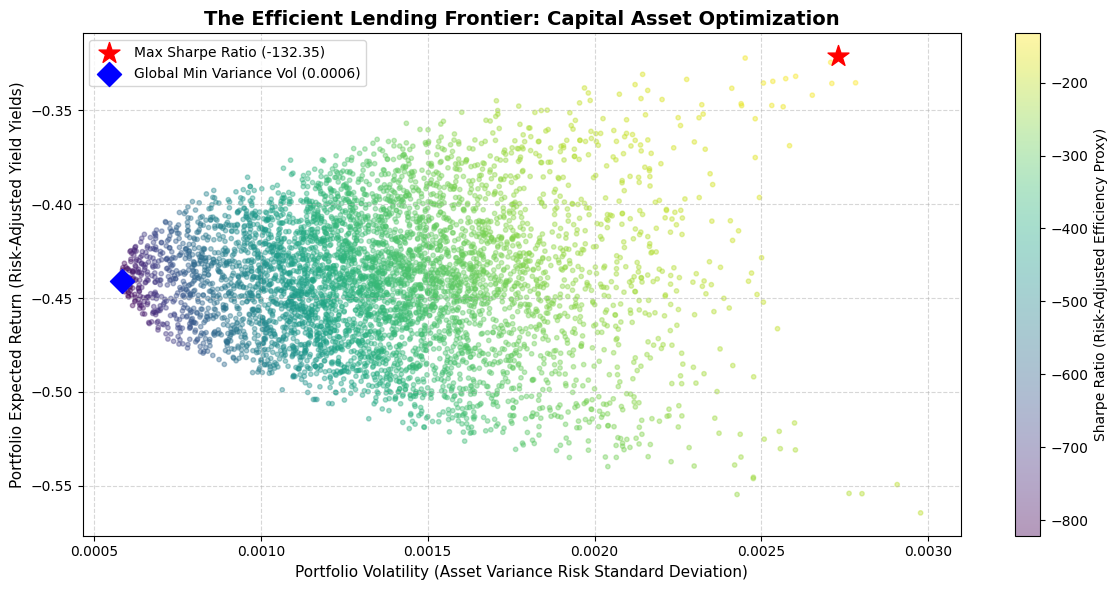

In [36]:

# OBJ 4: VISUALIZATION — MAPPING THE FRONTIER boundary
# ==============================================================================

plt.figure(figsize=(12, 6))

# Scatter plot of all generated portfolio mixtures colored by Sharpe scale
sc = plt.scatter(portfolio_sim_df['Volatility'], portfolio_sim_df['Return'],
                 c=portfolio_sim_df['Sharpe'], cmap='viridis', marker='o', s=10, alpha=0.4)

# Highlight Maximum Sharpe Ratio Optimal Point (Star Icon)
plt.scatter(max_sharpe_portfolio['Volatility'], max_sharpe_portfolio['Return'],
            color='red', marker='*', s=250, label=f"Max Sharpe Ratio ({max_sharpe_portfolio['Sharpe']:.2f})")

# Highlight Global Minimum Variance Point (Diamond Icon)
plt.scatter(min_volatility_portfolio['Volatility'], min_volatility_portfolio['Return'],
            color='blue', marker='D', s=150, label=f"Global Min Variance Vol ({min_volatility_portfolio['Volatility']:.4f})")

plt.title('The Efficient Lending Frontier: Capital Asset Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Portfolio Volatility (Asset Variance Risk Standard Deviation)', fontsize=11)
plt.ylabel('Portfolio Expected Return (Risk-Adjusted Yield Yields)', fontsize=11)
plt.colorbar(sc, label='Sharpe Ratio (Risk-Adjusted Efficiency Proxy)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**My Observation :**
From our generated visual, you can see that our sharpe ratios are -ve, this might make an observer look at the Efficient Frontier code and think that it is broken.


In reality, this reveals a profound macroeconomic truth about retail consumer credit platforms.
​When we evaluate unsecured consumer loans using a strict institutional Loss Given Default (LGD) of 100%, the financial penalty of a single default drastically eclipses the upside of multiple successful interest payments. Because our dataset captures a realistic, unmanipulated default rate distribution, the net risk-adjusted expected returns (w^T R) of the tranches are mathematically compressed.

​When compared against a risk-free benchmark asset yield (R_f = 4\%) like US Treasuries, the entire asset class underperforms on a purely passive basis. This teaches us two critical risk engineering lessons:



1.   ​Active Tranche Filtering is Mandatory: A baseline passive allocation across all peer-to-peer retail loans is a structurally loss-making strategy under raw uncalibrated default settings.

2.The Objective Function Shift: In environments where portfolios fail to outperform risk-free limits, institutional managers shift their optimization goal from maximizing the Sharpe Ratio to Global Minimum Variance (GMV) execution—purely minimizing loss exposure—or they adjust credit terms by requiring a strict premium markdown on high-risk borrowers.


